## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

## Training

In [2]:
# -----------------------------
# Experiment settings
# -----------------------------
random_state = 42

minority_samples = 1000

imbalance_ratios = [
    10, 100, 500, 1000, 5000,
]

n_splits = 5

# roc_auc and average_precision are reported as-is (higher = better).
# neg_log_loss is reported with a flipped sign (higher = better), so we
# negate it back to actual log loss (lower = better) during preparation.
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "log_loss": "neg_log_loss",
}

rf_results = []
xgb_results = []

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=random_state
)

# -----------------------------
# Run experiment
# -----------------------------
for ir in imbalance_ratios:

    majority_samples = minority_samples * ir
    total_samples = majority_samples + minority_samples

    weights = [
        majority_samples / total_samples,
        minority_samples / total_samples,
    ]

    X, y = make_classification(
        n_samples=total_samples,
        n_features=20,
        n_informative=10,
        n_redundant=5,
        n_repeated=0,
        n_classes=2,
        weights=weights,
        flip_y=0,
        class_sep=0.7,
        random_state=random_state,
    )

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1
    )

    xgb = XGBClassifier(
        random_state=random_state,
        n_jobs=-1
    )

    rf_scores = cross_validate(
        rf,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    xgb_scores = cross_validate(
        xgb,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rf_results.append(rf_scores)
    xgb_results.append(xgb_scores)

    print(
        f"IR {ir:4d}:1 | "
        f"RF ROC-AUC = {rf_scores['test_roc_auc'].mean():.4f} \u00b1 {rf_scores['test_roc_auc'].std():.4f} | "
        f"XGB ROC-AUC = {xgb_scores['test_roc_auc'].mean():.4f} \u00b1 {xgb_scores['test_roc_auc'].std():.4f}"
    )


IR   10:1 | RF ROC-AUC = 0.9746 ± 0.0062 | XGB ROC-AUC = 0.9824 ± 0.0046
IR  100:1 | RF ROC-AUC = 0.9512 ± 0.0101 | XGB ROC-AUC = 0.9760 ± 0.0044
IR  500:1 | RF ROC-AUC = 0.9389 ± 0.0080 | XGB ROC-AUC = 0.9478 ± 0.0173
IR 1000:1 | RF ROC-AUC = 0.9267 ± 0.0088 | XGB ROC-AUC = 0.9877 ± 0.0021
IR 5000:1 | RF ROC-AUC = 0.8650 ± 0.0109 | XGB ROC-AUC = 0.9636 ± 0.0056


KeyboardInterrupt: 

## Prepare results

In [5]:
# -----------------------------
# Prepare results
# -----------------------------
metrics = ["roc_auc", "average_precision", "log_loss"]

rf_stats = {metric: {"mean": [], "std": []} for metric in metrics}
xgb_stats = {metric: {"mean": [], "std": []} for metric in metrics}

imbalance_ratios = [
    10, 100, 500, 1000, 5000,
]

for rf_scores, xgb_scores in zip(rf_results, xgb_results):
    for metric in metrics:
        # neg_log_loss comes back with a flipped sign; undo it so lower = worse, as expected
        sign = -1 if metric == "log_loss" else 1

        rf_vals = sign * rf_scores[f"test_{metric}"]
        xgb_vals = sign * xgb_scores[f"test_{metric}"]

        rf_stats[metric]["mean"].append(rf_vals.mean())
        rf_stats[metric]["std"].append(rf_vals.std())

        xgb_stats[metric]["mean"].append(xgb_vals.mean())
        xgb_stats[metric]["std"].append(xgb_vals.std())


def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        imbalance_ratios,
        rf_stats[metric]["mean"],
        yerr=rf_stats[metric]["std"],
        marker="o",
        capsize=4,
        label="Random Forest"
    )

    plt.errorbar(
        imbalance_ratios,
        xgb_stats[metric]["mean"],
        yerr=xgb_stats[metric]["std"],
        marker="s",
        capsize=4,
        label="XGBoost"
    )

    plt.xscale("log")
    plt.xticks(imbalance_ratios, imbalance_ratios)

    plt.xlabel("Imbalance Ratio (Majority : Minority)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Plot ROC-AUC

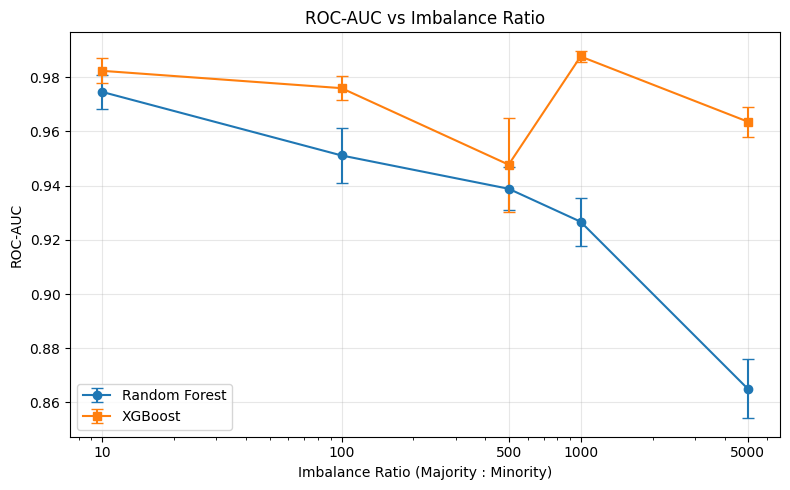

In [6]:
plot_metric("roc_auc", "ROC-AUC", "ROC-AUC vs Imbalance Ratio")

## Plot Average Precision

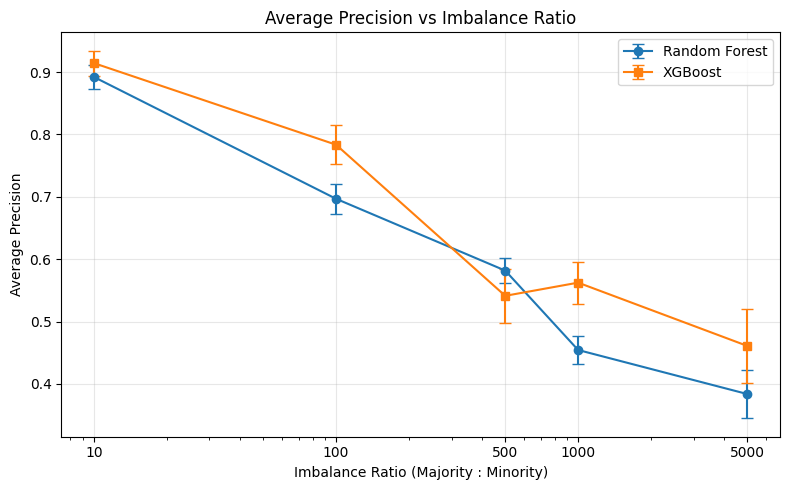

In [7]:
plot_metric("average_precision", "Average Precision", "Average Precision vs Imbalance Ratio")

## Plot Log Loss

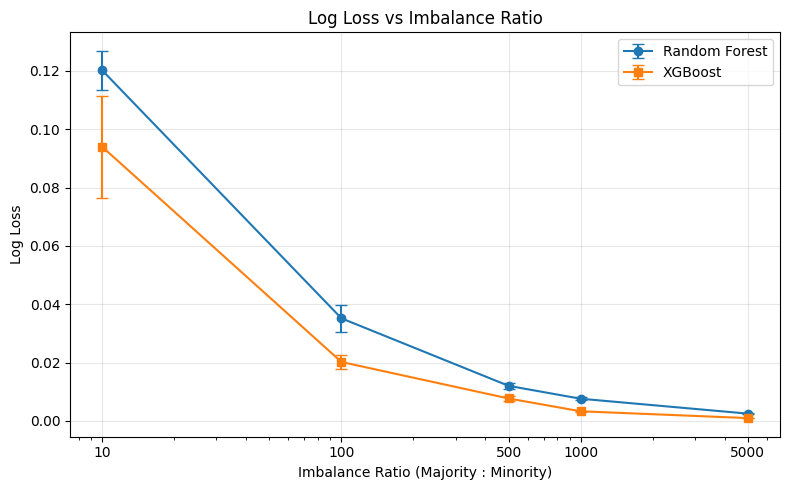

In [8]:
plot_metric("log_loss", "Log Loss", "Log Loss vs Imbalance Ratio")